In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# ------------------------------------------------------------
# 1. Загрузка модели
# ------------------------------------------------------------
MODEL_PATH = 'checkpoints/best_model_r.h5'
model = tf.keras.models.load_model(MODEL_PATH)
print("Модель загружена успешно")
model.summary()


Модель загружена успешно


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,341 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [6]:
# ------------------------------------------------------------
# 2. Параметры для тестовых данных
# ------------------------------------------------------------
TEST_DIR = r'C:\Users\gabde\generated_images5'
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # нужны метки для матрицы
    shuffle=False               # важно, чтобы сохранить порядок
)

print(f"Найдено классов: {len(test_generator.class_indices)}")
print(f"Классы: {test_generator.class_indices}")

Found 2400 images belonging to 3 classes.
Найдено классов: 3
Классы: {'Anthracnose_generated': 0, 'Downy Mildew': 1, 'Fresh Leaf': 2}


In [7]:
# ------------------------------------------------------------
# 3. Предсказания
# ------------------------------------------------------------
steps = test_generator.samples // BATCH_SIZE
if test_generator.samples % BATCH_SIZE != 0:
    steps += 1

predictions = model.predict(test_generator, steps=steps, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes  # истинные метки (индексы)
class_names = list(test_generator.class_indices.keys())  # имена классов в порядке индексов

75/75 ━━━━━━━━━━━━━━━━━━━━ 25s 335ms/step


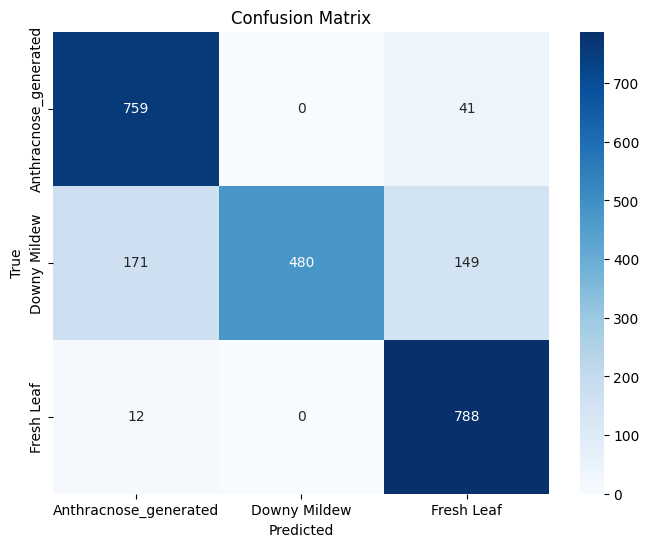


Classification Report:
                       precision    recall  f1-score   support

Anthracnose_generated       0.81      0.95      0.87       800
         Downy Mildew       1.00      0.60      0.75       800
           Fresh Leaf       0.81      0.98      0.89       800

             accuracy                           0.84      2400
            macro avg       0.87      0.84      0.84      2400
         weighted avg       0.87      0.84      0.84      2400



In [8]:
# ------------------------------------------------------------
# 4. Матрица ошибок и отчёт
# ------------------------------------------------------------
# Вычисляем матрицу
cm = confusion_matrix(true_classes, predicted_classes)

# Визуализация с помощью seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Печать отчёта о классификации (точность, полнота, f1-мера)
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))